In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
end_date = datetime.now()
start_date = end_date - timedelta(days=365*10)  

In [3]:
ticker_1 = input("Inserisci il ticker del primo titolo: ")
ticker_2 = input("Inserisci il ticker del secondo titolo: ")

Inserisci il ticker del primo titolo:  NVDA
Inserisci il ticker del secondo titolo:  WMT


In [4]:
data1 = yf.download(ticker_1,start=start_date,end=end_date,interval='1mo')
data2 = yf.download(ticker_2,start=start_date,end=end_date,interval='1mo')

print(data1)
print(data2)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker            NVDA        NVDA        NVDA        NVDA        NVDA
Date                                                                  
2015-09-01    0.599070    0.599799    0.520085    0.530535  6480208000
2015-10-01    0.689477    0.699441    0.570392    0.599070  8052316000
2015-11-01    0.770892    0.776239    0.671493    0.691664  7344816000
2015-12-01    0.804069    0.827977    0.779918    0.780650  5627172000
2016-01-01    0.714539    0.815779    0.645256    0.787725  8138980000
...                ...         ...         ...         ...         ...
2025-03-01  108.362511  123.680039  103.633278  123.490074  6177950300
2025-04-01  108.912437  115.092009   86.613990  108.512464  6811006400
2025-05-01  135.120621  143.480041  110.812304  113.072149  4756803800
2025-06-01  157.979034  158.698986  135.390592  135.480597  3821296800
2025-07-01  177.869995  183.300003  151.490005  156.289993  3595627800

[119 

In [5]:
returns_df = pd.DataFrame()
returns_df[ticker_1] = data1['Close'].pct_change()
returns_df[ticker_2] = data2['Close'].pct_change()
returns_df = returns_df.dropna()

print(returns_df)

                NVDA       WMT
Date                          
2015-10-01  0.150913 -0.117211
2015-11-01  0.118083  0.027952
2015-12-01  0.043038  0.041808
2016-01-01 -0.111347  0.091612
2016-02-01  0.070673 -0.000301
...              ...       ...
2025-03-01 -0.132405 -0.109725
2025-04-01  0.005075  0.110799
2025-05-01  0.240635  0.015116
2025-06-01  0.169170 -0.007127
2025-07-01  0.125909  0.002045

[118 rows x 2 columns]


In [6]:
statistics_df = pd.DataFrame({
    "Expected Returns": returns_df.mean(),
    "Variance": returns_df.var(),
    "Standard Deviation": returns_df.std()
})

print(statistics_df)

      Expected Returns  Variance  Standard Deviation
NVDA          0.058553  0.018852            0.137302
WMT           0.015976  0.002984            0.054623


In [7]:
corr = returns_df[ticker_1].corr(returns_df[ticker_2])
corr = np.round(corr,6)

print(corr)

0.211436


In [8]:
weights = [round(x * 0.01, 2) for x in range(0, 101)]
print(weights)

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6, 0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7, 0.71, 0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8, 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.0]


In [9]:
p_exp_return = []
p_variance = []
p_stdev = []

t1_er = statistics_df.loc[ticker_1, 'Expected Returns']
t2_er = statistics_df.loc[ticker_2, 'Expected Returns']
t1_var = statistics_df.loc[ticker_1, 'Variance'] 
t2_var = statistics_df.loc[ticker_2, 'Variance']
t1_sd = statistics_df.loc[ticker_1, 'Standard Deviation']
t2_sd = statistics_df.loc[ticker_2, 'Standard Deviation']

for w in weights:
    
    p_er = t1_er * w + t2_er * (1 - w)
    p_exp_return.append(float(p_er))

    p_var = t1_var*(w**2) + t2_var*((1-w)**2) + 2*w*(1-w)*t1_sd*t2_sd*corr
    p_variance.append(p_var)

    p_sd = np.sqrt(p_var)
    p_stdev.append(p_sd)

In [10]:
portfolio_df = pd.DataFrame({
    "Weights": weights,
    "Portfolio ER": p_exp_return,
    "Portfolio Var": p_variance,
    "Portfolio SD": p_stdev,
})

print(portfolio_df)

     Weights  Portfolio ER  Portfolio Var  Portfolio SD
0       0.00      0.015976       0.002984      0.054623
1       0.01      0.016401       0.002958      0.054383
2       0.02      0.016827       0.002935      0.054178
3       0.03      0.017253       0.002917      0.054005
4       0.04      0.017679       0.002902      0.053867
..       ...           ...            ...           ...
96      0.96      0.056850       0.017500      0.132289
97      0.97      0.057276       0.017833      0.133539
98      0.98      0.057702       0.018169      0.134791
99      0.99      0.058127       0.018508      0.136045
100     1.00      0.058553       0.018852      0.137302

[101 rows x 4 columns]


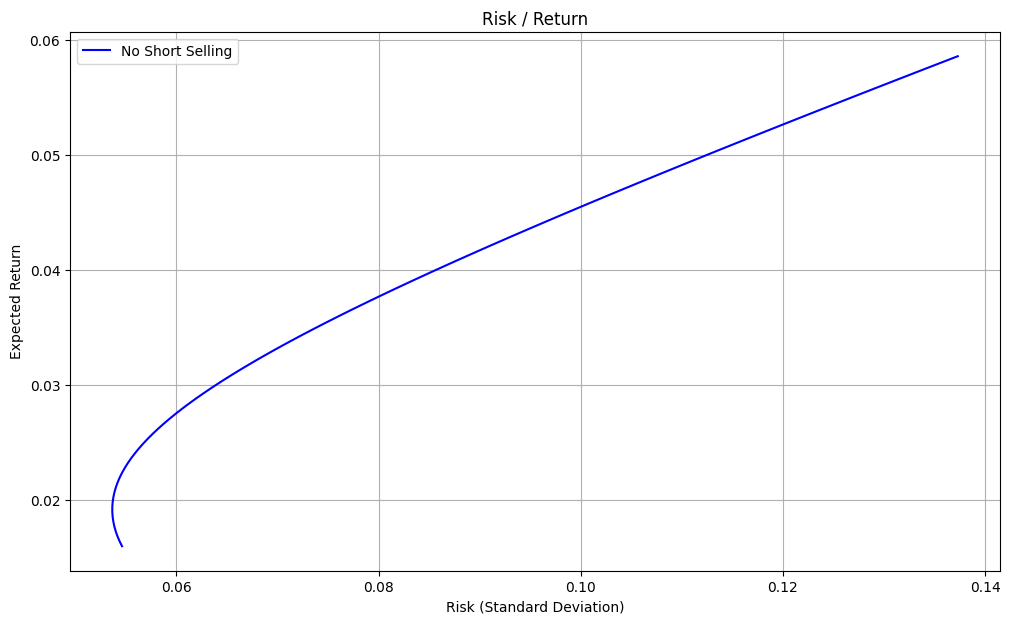

In [18]:
plt.figure(figsize=(12,7))
plt.plot(p_stdev, p_exp_return, '-b', label='No Short Selling')

plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Risk / Return')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
weights2 = [round(x * 0.01, 2) for x in range(-100, 201)]
print(weights2)

[-1.0, -0.99, -0.98, -0.97, -0.96, -0.95, -0.94, -0.93, -0.92, -0.91, -0.9, -0.89, -0.88, -0.87, -0.86, -0.85, -0.84, -0.83, -0.82, -0.81, -0.8, -0.79, -0.78, -0.77, -0.76, -0.75, -0.74, -0.73, -0.72, -0.71, -0.7, -0.69, -0.68, -0.67, -0.66, -0.65, -0.64, -0.63, -0.62, -0.61, -0.6, -0.59, -0.58, -0.57, -0.56, -0.55, -0.54, -0.53, -0.52, -0.51, -0.5, -0.49, -0.48, -0.47, -0.46, -0.45, -0.44, -0.43, -0.42, -0.41, -0.4, -0.39, -0.38, -0.37, -0.36, -0.35, -0.34, -0.33, -0.32, -0.31, -0.3, -0.29, -0.28, -0.27, -0.26, -0.25, -0.24, -0.23, -0.22, -0.21, -0.2, -0.19, -0.18, -0.17, -0.16, -0.15, -0.14, -0.13, -0.12, -0.11, -0.1, -0.09, -0.08, -0.07, -0.06, -0.05, -0.04, -0.03, -0.02, -0.01, 0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4, 0.41, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.51, 0.5

In [13]:
p_er_short_selling = []
p_variance_short_selling = []
p_stdev_short_selling = []

for w in weights2:
    
    p_er = t1_er * w + t2_er * (1 - w)
    p_er_short_selling.append(float(p_er))

    p_var = t1_var*(w**2) + t2_var*((1-w)**2) + 2*w*(1-w)*t1_sd*t2_sd*corr
    p_variance_short_selling.append(p_var)

    p_sd = np.sqrt(p_var)
    p_stdev_short_selling.append(p_sd)

In [14]:
portfolio_short_selling_df = pd.DataFrame({
    "Weights": weights2,
    "Portfolio ER": p_er_short_selling,
    "Portfolio Var": p_variance_short_selling,
    "Portfolio SD": p_stdev_short_selling,
})

print(portfolio_short_selling_df)

     Weights  Portfolio ER  Portfolio Var  Portfolio SD
0      -1.00     -0.026602       0.024443      0.156344
1      -0.99     -0.026176       0.024044      0.155062
2      -0.98     -0.025750       0.023648      0.153781
3      -0.97     -0.025324       0.023257      0.152501
4      -0.96     -0.024899       0.022868      0.151223
..       ...           ...            ...           ...
296     1.96      0.099428       0.069203      0.263065
297     1.97      0.099853       0.069909      0.264403
298     1.98      0.100279       0.070618      0.265741
299     1.99      0.100705       0.071331      0.267079
300     2.00      0.101131       0.072048      0.268417

[301 rows x 4 columns]


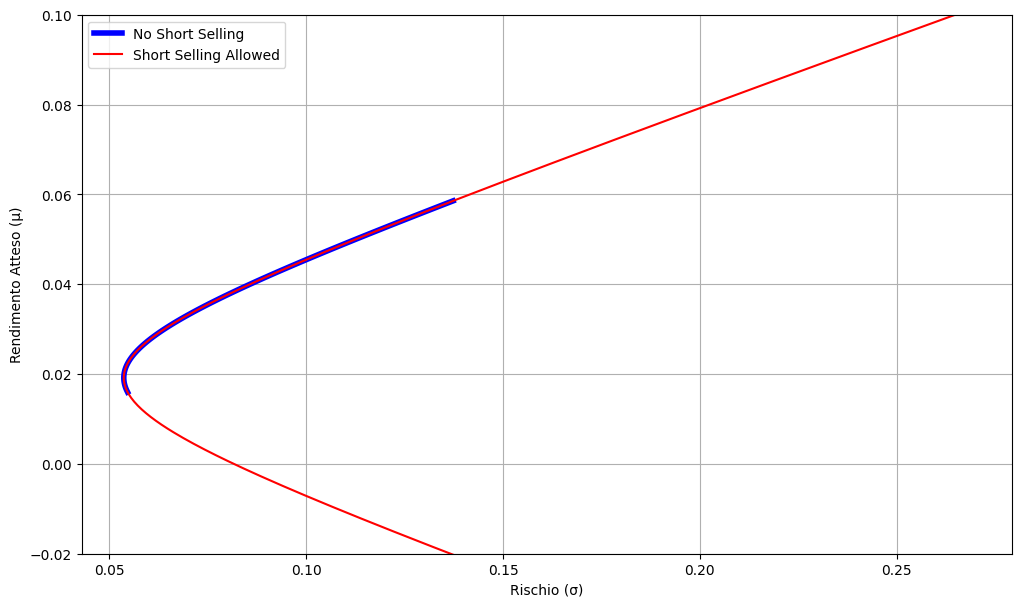

In [20]:
plt.figure(figsize=(12,7))

plt.plot(p_stdev,
         p_exp_return,
         color='blue',
         linewidth=4,
         label='No Short Selling')

plt.plot(p_stdev_short_selling, 
         p_er_short_selling, 
         color='red', 
         label='Short Selling Allowed')

plt.xlabel('Rischio (σ)')
plt.ylabel('Rendimento Atteso (µ)')
plt.legend()
plt.ylim(-0.02,0.1)
plt.grid(True)
plt.show()